In [1]:
import os
import chromadb
import warnings
warnings.filterwarnings("ignore")
from langchain_openai import OpenAIEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain.schema.runnable import RunnablePassthrough
from langchain.schema.output_parser import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_community.tools import TavilySearchResults
from langchain_core.messages import HumanMessage
from langgraph.prebuilt import create_react_agent, ToolNode
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import END, StateGraph, MessagesState, START
from langchain_core.tools import tool
from typing import Literal
from langchain_community.document_loaders import WebBaseLoader, TextLoader
from langchain_community.vectorstores import FAISS
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langgraph.graph import Graph
from langchain.vectorstores import Chroma

USER_AGENT environment variable not set, consider setting it to identify your requests.


In [2]:
load_dotenv()

True

In [3]:
embeddings = OpenAIEmbeddings()
parser = StrOutputParser()
llm = ChatOpenAI()

In [4]:
from IPython.display import Image, display
def displayGraph(app):
    try:
        display(Image(app.get_graph().draw_mermaid_png()))
    except Exception as e:
        # This requires some extra dependencies and is optional
        print(e)

Workflow 1: Basic Graph with Chatbot

MessagesState:
MessagesState is a TypedDict that defines the state structure for managing messages in a chat workflow.

In [5]:
# class MessagesState(TypedDict):
#     messages: Annotated[list[AnyMessage], add_messages]
# https://github.com/langchain-ai/langgraph/blob/6082bcf8d3899ce1ed98f3e9e1967b4660abd1d5/libs/langgraph/langgraph/graph/message.py#L274

In [6]:
def llm_call(state: MessagesState):
    messages = state['messages']
    response = llm.invoke(messages)
    return {'messages':[response]}

In [7]:
workflow=StateGraph(MessagesState)
workflow.add_node("chatbot",llm_call)
workflow.add_edge(START, "chatbot")
workflow.add_edge("chatbot",END)
app=workflow.compile()

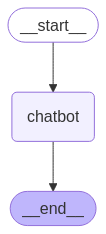

In [8]:
displayGraph(app)

In [9]:
input={"messages":["hi, my name is sunny"]}
app.invoke(input)

{'messages': [HumanMessage(content='hi, my name is sunny', additional_kwargs={}, response_metadata={}, id='dfe06579-88b0-48d8-9c1a-9d00b8d5a332'),
  AIMessage(content='Hello Sunny! How can I assist you today?', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 11, 'prompt_tokens': 13, 'total_tokens': 24, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BNNUPThlabYOmOtTewHoOIbz7nzpB', 'finish_reason': 'stop', 'logprobs': None}, id='run-5615d256-b69c-4195-87f7-9bb50b8b3f26-0', usage_metadata={'input_tokens': 13, 'output_tokens': 11, 'total_tokens': 24, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

Workflow 2: Graph with Agent & Custom Tool

In [10]:
@tool
def search(query: str):
    """this is my custom tool."""
    if "sf" in query.lower() or "san francisco" in query.lower():
        return "It's 60 degrees and foggy."
    return "It's 90 degrees and sunny."

In [11]:
tools = [search]

In [12]:
tool_node = ToolNode(tools)
llm_with_tool=llm.bind_tools(tools) #Need to bind LLM with the tool so that it can take decision whether to utilize the tool or not

In [13]:
def call_model(state: MessagesState):
    messages = state['messages']
    response = llm_with_tool.invoke(messages) #Use llm_with_tool instead of llm
    return {"messages": [response]}

In [14]:
call_model({"messages": ["hi how are you?"]})

{'messages': [AIMessage(content="Hello! I'm here and ready to assist you. How can I help you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 20, 'prompt_tokens': 48, 'total_tokens': 68, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BNNUQtPTjUHp6u2gwm7bhAaaJqnnk', 'finish_reason': 'stop', 'logprobs': None}, id='run-3932897a-7552-4054-b3cb-7a5e25b57e99-0', usage_metadata={'input_tokens': 48, 'output_tokens': 20, 'total_tokens': 68, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0, 'reasoning': 0}})]}

In [15]:
response = call_model({"messages": ["What's the weather in sf?"]})
response

{'messages': [AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_JcfHE9wzbcwuKlw1MlvuoZoL', 'function': {'arguments': '{"query":"weather in San Francisco"}', 'name': 'search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 50, 'total_tokens': 67, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BNNURRbbhIXqBuIxPUi1iibpD7v55', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-a913f152-8bb9-449e-8d80-315fbee3b9ed-0', tool_calls=[{'name': 'search', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_JcfHE9wzbcwuKlw1MlvuoZoL', 'type': 'tool_call'}], usage_metadata={'input_tokens': 50, 'output_tokens': 17, 'total_tokens': 67, 'input_token_details': {'audio

In [16]:
response['messages'][-1].tool_calls

[{'name': 'search',
  'args': {'query': 'weather in San Francisco'},
  'id': 'call_JcfHE9wzbcwuKlw1MlvuoZoL',
  'type': 'tool_call'}]

In [17]:
def router(state: MessagesState) -> Literal["tools", END]:
    messages = state['messages']
    last_message = messages[-1]
    if last_message.tool_calls:
        return "tools"
    return END

In [18]:
workflow = StateGraph(MessagesState)
workflow.add_node("agent", call_model)
workflow.add_node("tools", tool_node)
workflow.add_edge(START, "agent")
workflow.add_conditional_edges(
    "agent",
    router,
    {
        "tools": "tools",
        END: END,
    }
)
app = workflow.compile()

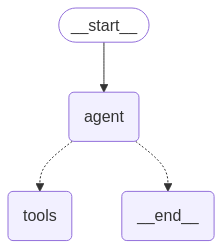

In [19]:
displayGraph(app)

In [20]:
app.invoke({"messages": ["hi how are you?"]})

{'messages': [HumanMessage(content='hi how are you?', additional_kwargs={}, response_metadata={}, id='fa4ac563-a5ae-466f-a9ad-a002c3d73b33'),
  AIMessage(content="I'm just a computer program, so I don't have feelings, but I'm here and ready to help you! How can I assist you today?", additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 33, 'prompt_tokens': 48, 'total_tokens': 81, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BNNVVRPt0eCB1ueSnoqs6CW76zkra', 'finish_reason': 'stop', 'logprobs': None}, id='run-edbfd0cf-59de-40b0-8b4c-e6dcf3d9cc60-0', usage_metadata={'input_tokens': 48, 'output_tokens': 33, 'total_tokens': 81, 'input_token_details': {'audio': 0, 'cache_read': 0}, 'output_token_details': {'audio': 0,

In [21]:
app.invoke({"messages": ["what is the weather in sf"]})

{'messages': [HumanMessage(content='what is the weather in sf', additional_kwargs={}, response_metadata={}, id='96b333b6-4e69-4db4-b71b-8294470b1adb'),
  AIMessage(content='', additional_kwargs={'tool_calls': [{'id': 'call_4SADdG17pPohAaIu8tXR3Urc', 'function': {'arguments': '{"query":"weather in San Francisco"}', 'name': 'search'}, 'type': 'function'}], 'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 17, 'prompt_tokens': 49, 'total_tokens': 66, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-3.5-turbo-0125', 'system_fingerprint': None, 'id': 'chatcmpl-BNNViMET5vjtLQVGexjQJqNain5AO', 'finish_reason': 'tool_calls', 'logprobs': None}, id='run-0077c463-0019-43fa-a84b-0848f7f1a04f-0', tool_calls=[{'name': 'search', 'args': {'query': 'weather in San Francisco'}, 'id': 'call_4SADdG17pPohAaIu8